# Análisis Exploratorio de Datos (EDA) - Wholesale Customers
**Grupo 06**

## Objetivo de este Notebook
El propósito de este análisis exploratorio no es solo visualizar los datos, sino fundamentar las decisiones técnicas que tomaremos en las etapas de **Data Cleaning** y **Feature Pipeline** antes del entrenamiento del modelo de Clustering. 

Analizaremos tres dimensiones críticas para algoritmos basados en distancias (como K-Means):
1. **Distribución y Asimetría (Skewness)**
2. **Presencia de Valores Atípicos (Outliers)**
3. **Correlación entre Variables**

--- Valores de Asimetría (Skewness) ---
Nota: Valores > 1 indican alta asimetría positiva



Delicassen          11.151586
Frozen               5.907986
Milk                 4.053755
Detergents_Paper     3.631851
Grocery              3.587429
Fresh                2.561323
dtype: float64

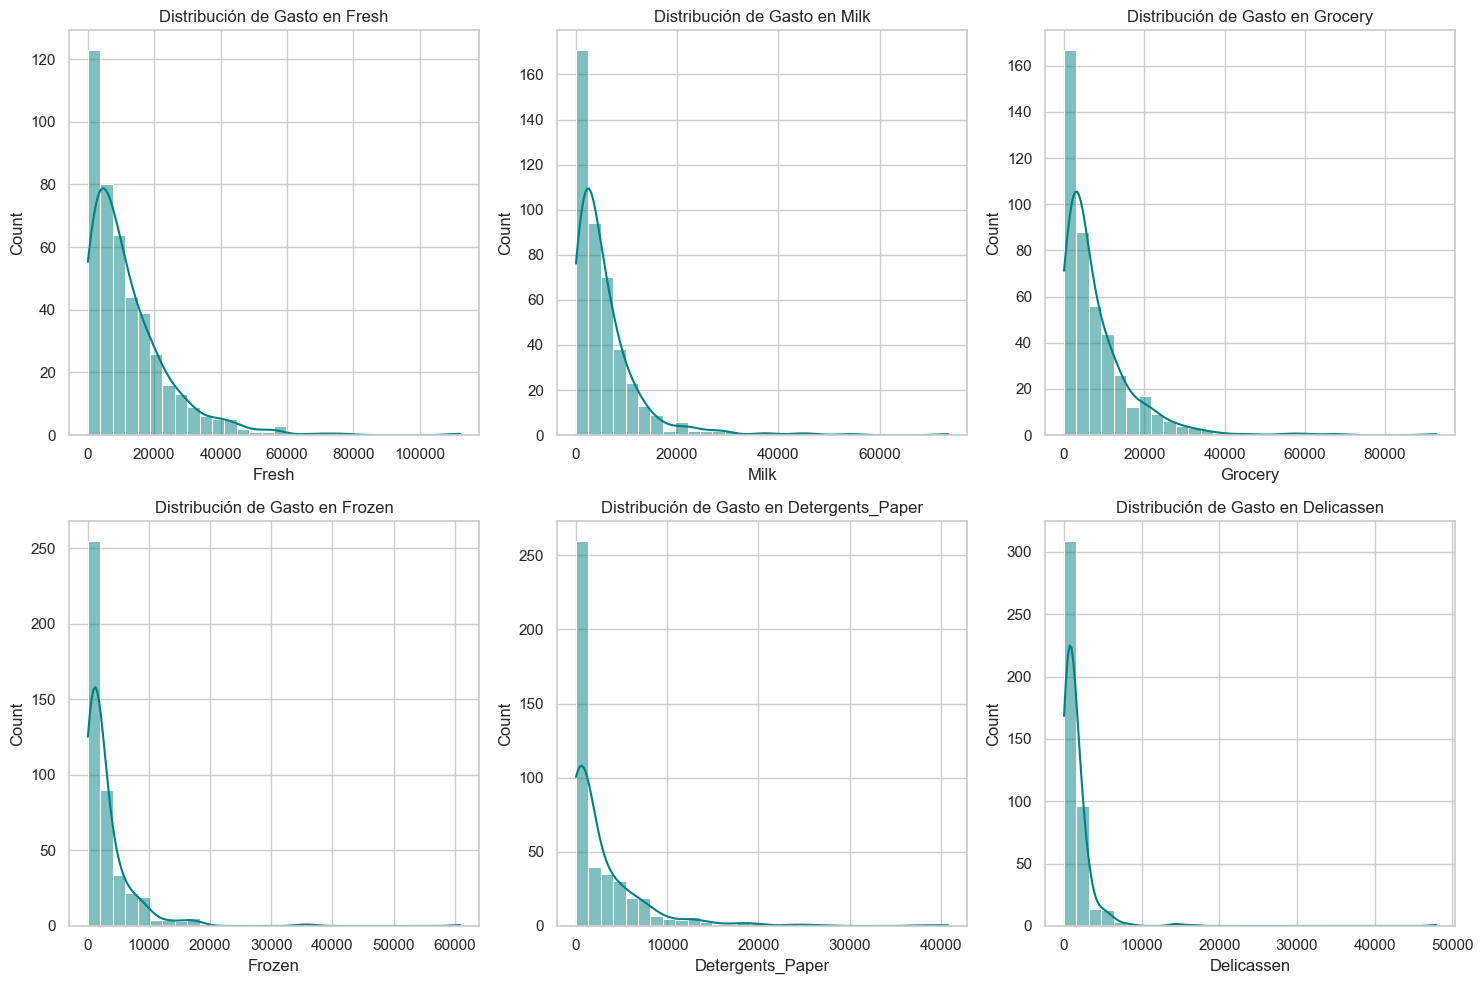

In [3]:
# 1. IMPORTACIONES Y CONFIGURACIÓN INICIAL
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual profesional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Cargar los datos crudos que superaron los Quality Gates
df = pd.read_csv("../data/raw/wholesale_customers.csv")

# Excluir variables categóricas (Channel y Region) para analizar solo el gasto
spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# 2. ANÁLISIS DE ASIMETRÍA (SKEWNESS)
print("--- Valores de Asimetría (Skewness) ---")
print("Nota: Valores > 1 indican alta asimetría positiva\n")
display(df[spending_cols].skew().sort_values(ascending=False))

# 3. VISUALIZACIÓN DE DISTRIBUCIONES
fig, axes = plt.subplots(2, 3)
for ax, col in zip(axes.flatten(), spending_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color='teal')
    ax.set_title(f'Distribución de Gasto en {col}')
    
plt.tight_layout()
plt.show()

### Conclusión Técnica 1: Distribuciones y Asimetría
* **Hallazgo:** Todas las variables de gasto presentan una asimetría positiva extrema (skewness muy superior a 1). La gran mayoría de los clientes gastan cantidades moderadas, pero un pequeño grupo gasta sumas millonarias, lo que alarga la cola de la distribución.
* **Decisión para el Feature Pipeline:** Los algoritmos de clustering basados en distancias son altamente sensibles a distribuciones sesgadas porque los centroides se ven arrastrados. En la fase de **Feature Engineering** aplicaremos una transformación no lineal (como `np.log1p` o `PowerTransformer`) para "normalizar" las distribuciones antes de escalar.

In [2]:
# --- 2. AUDITORÍA EXHAUSTIVA DE DATOS (Checklist del Profesor) ---
print("A. DUPLICADOS Y FALTANTES REALES")
print(f"Total Nulos: {df.isnull().sum().sum()}")
print(f"Total Duplicados: {df.duplicated().sum()}\n")

print("B. DATOS IMPOSIBLES Y ERRORES DE UNIDAD")
# Verificamos si algún cliente tiene gastos negativos (lo cual sería un error)
gastos_negativos = (df[spending_cols] < 0).sum().sum()
print(f"Total de registros con gastos negativos: {gastos_negativos}\n")

print("C. FALTANTES CODIFICADOS MEDIANTE SÍMBOLOS (Ceros sospechosos)")
# Contemos los ceros por columna
print("Cantidad de ceros por columna:")
print((df[spending_cols] == 0).sum())
print("\n")

print("D. CARDINALIDAD, CATEGORÍAS INCONSISTENTES E IMBALANCE")
print("Valores únicos en Region:", df['Region'].unique())
print("Valores únicos en Channel:", df['Channel'].unique())
print("\nDistribución de Channel (Imbalance):")
display(df['Channel'].value_counts(normalize=True).round(2))

A. DUPLICADOS Y FALTANTES REALES
Total Nulos: 0
Total Duplicados: 0

B. DATOS IMPOSIBLES Y ERRORES DE UNIDAD
Total de registros con gastos negativos: 0

C. FALTANTES CODIFICADOS MEDIANTE SÍMBOLOS (Ceros sospechosos)
Cantidad de ceros por columna:
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


D. CARDINALIDAD, CATEGORÍAS INCONSISTENTES E IMBALANCE
Valores únicos en Region: [3 1 2]
Valores únicos en Channel: [2 1]

Distribución de Channel (Imbalance):


Channel
1    0.68
2    0.32
Name: proportion, dtype: float64

### Decisiones de Auditoría de Datos
* **Datos imposibles y errores de unidad:** Confirmamos que no existen valores negativos en los gastos monetarios. La integridad aritmética se mantiene.
* **Valores faltantes codificados / Ceros:** Se detectaron 4 registros con valor '0' en *Delicassen* y 37 en *Fresh*. 
    * **Decisión:** Desde la lógica del negocio, es normal que un cliente mayorista no compre ciertos productos en todo el año. No son errores ni nulos codificados, son ceros reales. 
    * **Impacto en Pipeline:** Como tenemos ceros reales, se justifica matemáticamente el uso de una transformación como `np.log1p` (que suma 1 antes de transformar) en nuestro **Feature Pipeline**, ya que el logaritmo tradicional de 0 da error.
* **Cardinalidad e Inconsistencias:** Las variables categóricas (*Channel* y *Region*) tienen exactamente los valores únicos esperados (1, 2, 3). Se observa un imbalance natural, pero como eliminaremos estas columnas para el clustering no supervisado, no afectará al modelo.

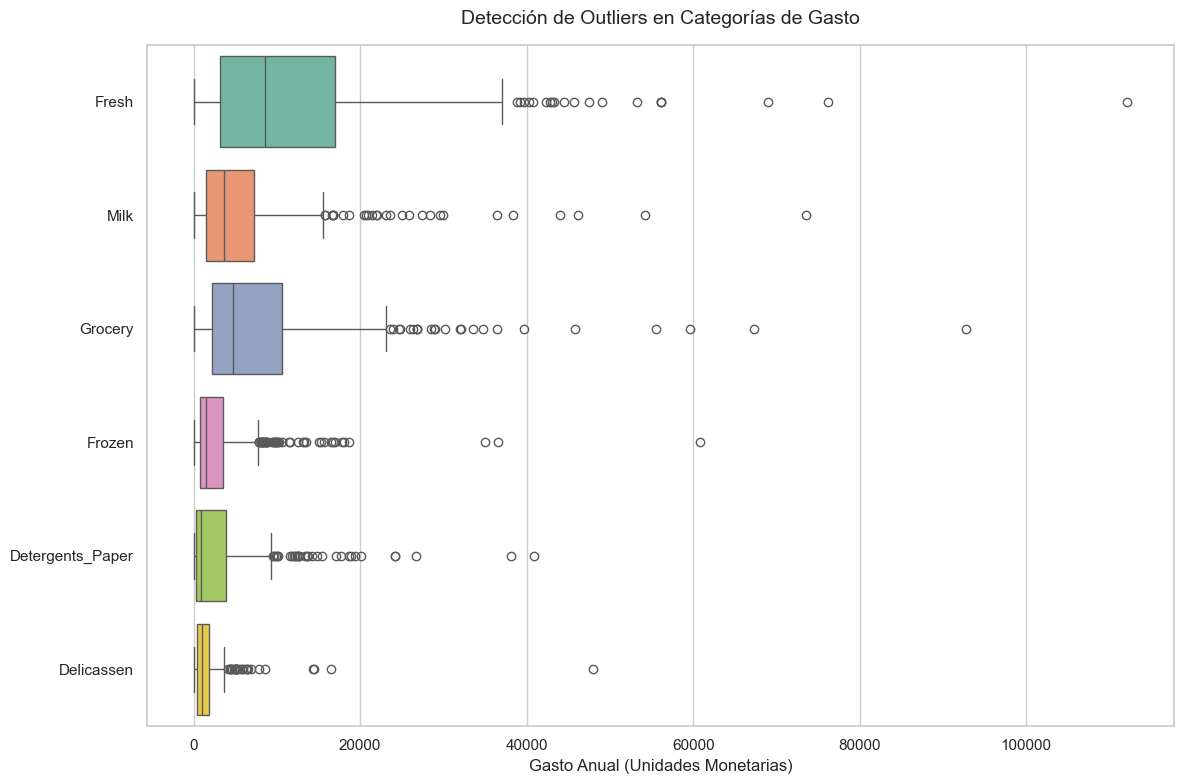


--- Cantidad de outliers detectados por variable (Método IQR) ---


Fresh               20
Milk                28
Grocery             24
Frozen              43
Detergents_Paper    30
Delicassen          27
dtype: int64

In [4]:
# 1. VISUALIZACIÓN CON BOXPLOTS
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[spending_cols], orient="h", palette="Set2")
plt.title("Detección de Outliers en Categorías de Gasto", fontsize=14, pad=15)
plt.xlabel("Gasto Anual (Unidades Monetarias)")
plt.tight_layout()
plt.show()

# 2. CONTEO MATEMÁTICO DE OUTLIERS (Método IQR)
Q1 = df[spending_cols].quantile(0.25)
Q3 = df[spending_cols].quantile(0.75)
IQR = Q3 - Q1

# Contar registros por encima del límite superior o debajo del inferior
outliers_count = ((df[spending_cols] < (Q1 - 1.5 * IQR)) | (df[spending_cols] > (Q3 + 1.5 * IQR))).sum()

print("\n--- Cantidad de outliers detectados por variable (Método IQR) ---")
display(outliers_count)

### Conclusión Técnica 2: Valores Atípicos (Outliers)
**Hallazgo:** Los boxplots evidencian una gran cantidad de valores atípicos superiores (clientes "ballena"). Esto tiene sentido en el contexto del negocio mayorista, ya que clientes como grandes cadenas de hoteles gastarán exponencialmente más que una cafetería pequeña.
* **Decisión para el Feature Pipeline:** No podemos eliminar (hacer *drop*) estos registros porque perderíamos a los clientes más valiosos de la empresa. En el **Feature Pipeline** utilizaremos un escalador robusto a valores extremos, como `RobustScaler` (que usa la mediana y el IQR), o aplicaremos una técnica de *Clipping/Winsorization* para acotar su efecto gravitacional sobre los clústeres.

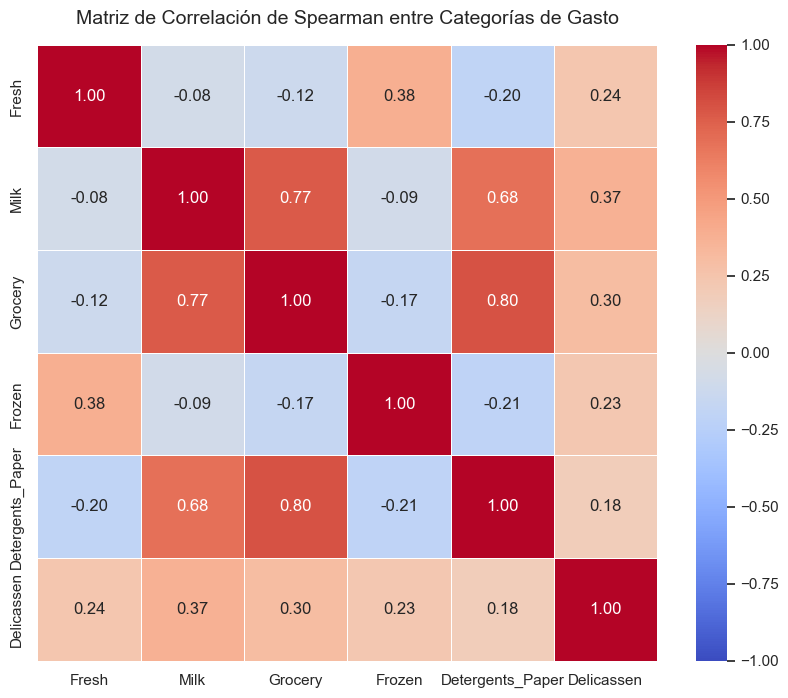

In [5]:
# ANÁLISIS DE CORRELACIÓN DE SPEARMAN 
# (Usamos Spearman en lugar de Pearson porque los datos no tienen distribución normal)

plt.figure(figsize=(10, 8))
correlation_matrix = df[spending_cols].corr(method='spearman')

# Crear un mapa de calor (Heatmap)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Spearman entre Categorías de Gasto", fontsize=14, pad=15)
plt.show()

### Conclusión Técnica 3: Correlaciones y Redundancia
* **Hallazgo:** Se observa una fuerte correlación positiva entre `Grocery` y `Detergents_Paper` (alta similitud de compra), y una correlación moderada-alta entre `Milk` y `Grocery`. Los clientes que compran abarrotes tienden a comprar detergentes y leche en proporciones similares.
* **Decisión para el Feature Pipeline:** Si bien hay correlación, no es lo suficientemente extrema (ej. > 0.95) como para descartar variables de inmediato (Feature Selection). Mantendremos todas las variables para el baseline del modelo, pero consideraremos aplicar PCA (Análisis de Componentes Principales) dentro del pipeline de MLflow si notamos que la dimensionalidad afecta el rendimiento del clustering.